In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [ ]:
%pip install pandas

In [ ]:
dataset = pd.read_csv("/content/2_letter_recognition.data", sep = ",")

In [ ]:
pip install -U scikit-learn

In [ ]:
X = dataset.iloc[:, 1 : 17]
Y = dataset.select_dtypes(include = [object])

In [ ]:
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size = 0.20, random_state = 10)

In [ ]:

scaler = StandardScaler()
scaler.fit(X_train)


,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [ ]:
X_train = scaler.transform(X_train)
X_validation = scaler.transform(X_validation)

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes = (250, 300), max_iter = 1000000, activation = 'logistic')

In [22]:
%pip install yellowbrick

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1223: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


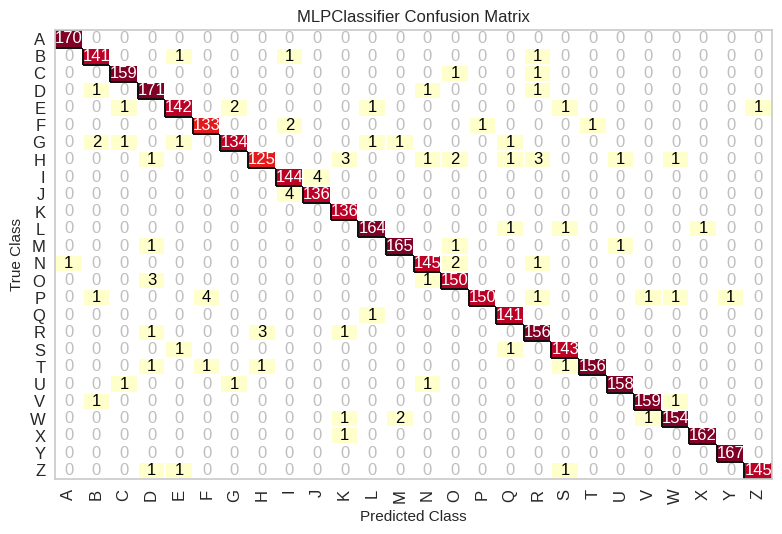

In [19]:
from yellowbrick.classifier import confusion_matrix

cm = confusion_matrix(
    mlp, X_train, Y_train, X_validation, Y_validation,
    classes="A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S,T,U,V,W,X,Y,Z".split(','),
    force_model=True  # ← add this
)

In [20]:
 !pip install yellowbrick

In [21]:
cm.fit(X_train, Y_train.values.ravel())

,estimator,MLPClassifier..._iter=1000000)
,ax,<Axes: title=...='True Class'>
,sample_weight,None
,percent,False
,classes,"['A', 'B', ...]"
,encoder,None
,cmap,<matplotlib.c...x7ed4b74a5580>
,fontsize,None
,is_fitted,'auto'
,force_model,True
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(250, ...)"


In [24]:
cm.score(X_validation, Y_validation)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.9765

In [25]:
predictions = cm.predict(X_validation)
predictions

array(['C', 'I', 'H', ..., 'H', 'B', 'W'], dtype='<U1')

In [26]:
print("Accuracy: ", accuracy_score(Y_validation, predictions))

Accuracy:  0.9765
